# 📊 Customer Churn Prediction using Machine Learning  
### **By: S. Himasri Chandana**

This project predicts whether a telecom customer will churn using Machine Learning techniques such as data preprocessing, encoding, Random Forest classification, evaluation, and real-time prediction.


## 📚 Table of Contents

1. **Introduction**
2. **Importing Libraries**
3. **Loading the Dataset**
4. **Exploratory Data Analysis (EDA)**
5. **Data Cleaning**
6. **Encoding Categorical Features**
7. **Feature & Target Selection**
8. **Train–Test Split**
9. **Model Training (Random Forest)**
10. **Model Evaluation**
11. **Feature Importance Analysis**
12. **Customer Churn Prediction (Demo)**
13. **Saving the Model**
14. **Conclusion**


## 1. 📘 Introduction

Customer churn refers to when a customer stops using a company's services.  
Predicting churn helps businesses improve customer retention and reduce revenue loss.

In this project, we use the **Telco Customer Churn dataset**, perform data cleaning, preprocessing, feature encoding, and train a **Random Forest classifier** to predict customer churn with strong accuracy.


## 2. 📦 Importing Libraries

We import all the necessary Python libraries for:

- Data analysis  
- Visualization  
- Machine learning  
- Model evaluation  
- Data preprocessing


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier


## 3. 📂 Loading the Dataset

We load the Telco Customer Churn dataset.  
This dataset contains information about customers, their subscriptions, services, charges, and whether they churned.


In [3]:
df = pd.read_csv("customer_churn.csv")  
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. 🔍 Exploratory Data Analysis (EDA)

In this step, we:

- Check dataset structure  
- View data types  
- Identify missing values  
- Understand basic statistical distribution  

EDA helps us understand the dataset before building a model.


In [4]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## 5. 🧹 Data Cleaning

We handle missing values by removing or processing them.  
Clean data ensures better model accuracy and reduces errors during training.


In [5]:
df = df.dropna()
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## 6. 🔤 Encoding Categorical Features

The dataset contains many categorical columns.  
We use **Label Encoding** to convert text-based categories into numeric values so the ML model can understand them.
ad()
ively.


In [6]:
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,2505,0
1,3962,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1466,0
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,157,1
3,5535,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1400,0
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,925,1


## 7. 🎯 Feature & Target Selection

We separate:

- **X** → independent features  
- **y** → target label (Churn)

This helps in training our ML model effectively.


In [7]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features:", X.columns)
print("Target:", y.head())


Features: Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges'],
      dtype='object')
Target: 0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int32


## 8. 🔀 Train–Test Split

We split the dataset into:

- **80% training data**  
- **20% testing data**

This helps us evaluate how well the model performs on unseen data.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## 9. 🌲 Model Training — Random Forest Classifier

We train a **Random Forest model**, which is robust, handles categorical variables well, and performs well on classification problems.

This model helps us predict whether a customer will churn.


In [9]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [11]:
y_pred = model.predict(X_test)


## 10. 📈 Model Evaluation

We evaluate the model using:

- **Accuracy Score**  
- **Classification Report**  
- **Confusion Matrix**

This helps us measure how well the model performs.
erforms.


Accuracy: 0.8097941802696949

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.91      0.88      1036
           1       0.68      0.52      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



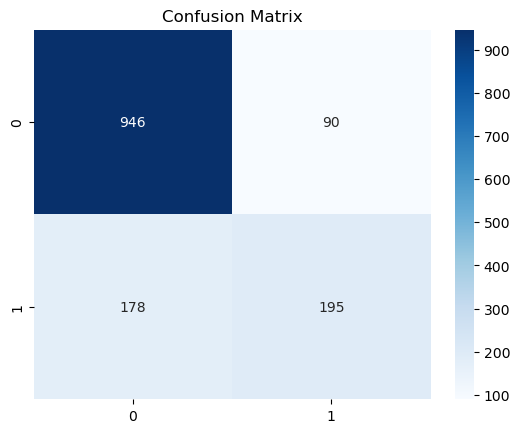

In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.savefig("images/confusion_matrix.png")
plt.show()



## 11. ⭐ Feature Importance Analysis

We analyze which features contribute the most to predicting churn.  
This helps businesses understand key churn factors such as:

- Monthly charges  
- Contract type  
- Tenure  
- Services used  


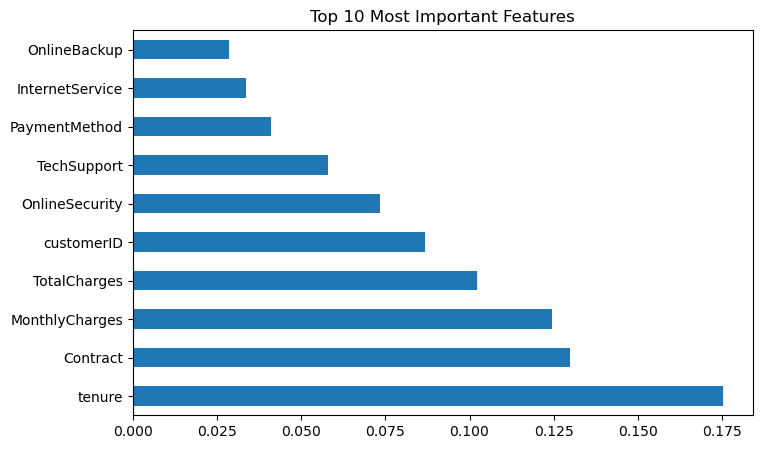

In [16]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind="barh", figsize=(8,5))
plt.title("Top 10 Most Important Features")
plt.savefig("images/feature_importance.png")
plt.show()


## 12. 🧪 Customer Churn Prediction (Demo)

We test the model on a sample customer data point to predict whether the customer will **stay** or **leave**.

This demonstrates real-world usage of the model.


In [17]:
new_customer = pd.DataFrame([{
    'customerID': 9999,
    'gender': 1,
    'SeniorCitizen': 0,
    'Partner': 1,
    'Dependents': 0,
    'tenure': 12,
    'PhoneService': 1,
    'MultipleLines': 0,
    'InternetService': 2,
    'OnlineSecurity': 0,
    'OnlineBackup': 1,
    'DeviceProtection': 0,
    'TechSupport': 0,
    'StreamingTV': 1,
    'StreamingMovies': 1,
    'Contract': 0,
    'PaperlessBilling': 1,
    'PaymentMethod': 2,
    'MonthlyCharges': 70.5,
    'TotalCharges': 845.0
}])

prediction = model.predict(new_customer)

print("Prediction:", "Customer will leave" if prediction[0] == 1 else "Customer will stay")


Prediction: Customer will stay


## 13. 💾 Saving the Model

We save the trained model using **pickle** so it can be used later in applications such as:

- Streamlit apps  
- Websites  
- Automation pipelines  


In [21]:
import pickle
pickle.dump(model, open("models/churn_model.pkl", "wb"))


## 14. 🏁 Conclusion

In this project, we successfully:

- Processed and cleaned telecom customer data  
- Encoded categorical features  
- Trained a Random Forest model  
- Achieved strong accuracy in predicting customer churn  
- Identified important churn factors  
- Built a real-time churn prediction system  

This model can help companies improve retention and reduce churn using data-driven insights.
